# **实验3: SVM实验**

姓名：李昌峻

学号：2023213851

提交要求：每周三20:00前提交，用pdf导出，在学习通上提交pdf文件和ipynb文件，命名方式：学号_实验X。

In [1]:
# 加载必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn import svm
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay

## Step 1: 加载数据集iris

In [2]:
# 导入数据集：(请勿删除备注，直接在下面输入代码，在Code下点击运行即可)
iris_data = datasets.load_iris()
iris_X = iris_data.data
iris_y = iris_data.target
iris_X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

## Step 2： 输出数据相关信息

In [3]:
# Step 2.1 输出特征名称：
print(iris_data.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [4]:
# Step 2.2 输出决策类名称：
print(iris_data.target_names)

['setosa' 'versicolor' 'virginica']


In [5]:
# Step 2.3 输出数据形状（即多少行，多少列）：
print(iris_X.shape)

(150, 4)


In [6]:
# Step 2.4 输出决策类形状（即多少行，多少列），注意查看输出 ：
print(iris_y.shape)

(150,)


In [7]:
# Step 2.5 输出前5个样本的数据
print(iris_X[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [8]:
# Step 2.6 输出前5个样本的决策标签
print(iris_y[:5])

[0 0 0 0 0]


## Step 3: 标准化特征数据，使每个特征的均值为0，方差为1。

In [9]:
#代码
X_mean = iris_X.mean(axis=0)
X_std_dev = iris_X.std(axis=0)
X_std = (iris_X - X_mean) / X_std_dev
X_std

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

## Step 3: 使用 PCA 将数据降到二维,并画出散点图
PCA请参考：https://blog.csdn.net/2301_81199775/article/details/138133215

In [10]:
#代码
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)
X_pca

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

###  Step 3.2  输出PCA降维后的决策表，并前5个样本的数据和前5个样本的决策标签

In [11]:
import pandas as pd
#代码
decision_table = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
decision_table['Label'] = iris_y
print(decision_table.head())

        PC1       PC2  Label
0 -2.264703  0.480027      0
1 -2.080961 -0.674134      0
2 -2.364229 -0.341908      0
3 -2.299384 -0.597395      0
4 -2.389842  0.646835      0


## Step 4：绘制降维后的散点图

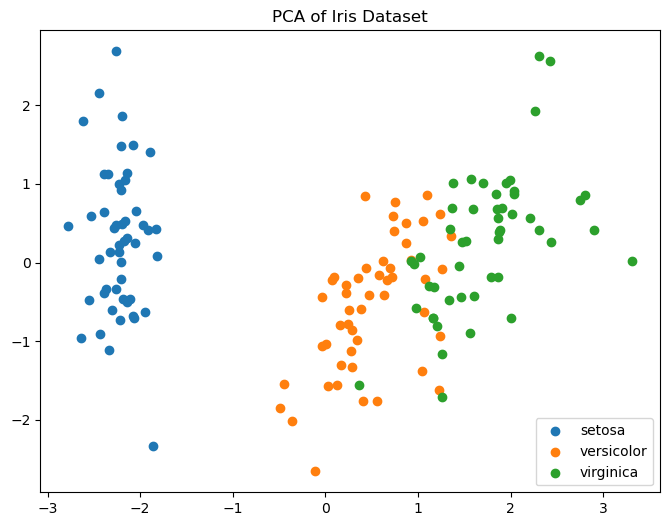

In [12]:
#代码
plt.figure(figsize=(8, 6))
for target in set(iris_y):
    plt.scatter(X_pca[iris_y == target, 0], X_pca[iris_y == target, 1], label=iris_data.target_names[target])
plt.legend()
plt.title('PCA of Iris Dataset')
plt.show()

## Step 5： 使用LinearSVC模型，对降维后的数据集进行分类

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, iris_y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape,y_test.shape)

(120, 2) (30, 2)
(120,) (30,)


In [14]:
#代码
lsvc = LinearSVC(dual = 'auto',max_iter=1000)
lsvc.fit(X_train, y_train)
print(lsvc.score(X_test, y_test))
y_pred = lsvc.predict(X_test)
print(y_pred)
print("分类报告:")
print(classification_report(y_test, y_pred))
print("混淆矩阵:")
print(confusion_matrix(y_test,y_pred))

0.9333333333333333
[1 0 2 1 2 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.78      0.88         9
           2       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

混淆矩阵:
[[10  0  0]
 [ 0  7  2]
 [ 0  0 11]]


## Step 6: 将数据集划分为训练集和测试集

In [15]:
#代码
X_train, X_test, y_train, y_test = train_test_split(X_pca, iris_y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape,y_test.shape)

(120, 2) (30, 2)
(120,) (30,)


## Step7 绘制决策边界与样本点

Text(0.5, 1.0, 'PCA of Iris Dataset with Decision Boundary')

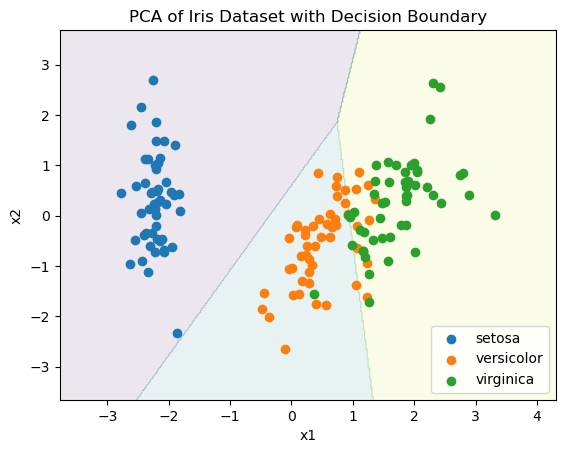

In [16]:
#代码
h = 0.02
# 第0列范围（+1，-1）
x_min,x_max = X_pca[:,0].min() - 1, X_pca[:,0].max() + 1
# 第1列
y_min,y_max = X_pca[:,1].min() - 1, X_pca[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = lsvc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.1)
for target in set(iris_y):
    plt.scatter(X_pca[iris_y == target, 0], X_pca[iris_y == target, 1], label=iris_data.target_names[target])
plt.legend() 
plt.ylabel('x2')
plt.xlabel('x1')
plt.title('PCA of Iris Dataset with Decision Boundary')


## Step 8： 对降维后的数据集进行十折交叉划分

In [17]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = []
all_y_true = []
all_y_pred = []
# 进行十折交叉验证
for train_index, test_index in kf.split(X_pca, iris_y):
    X_train, X_test = X_pca[train_index], X_pca[test_index]
    y_train, y_test = iris_y[train_index], iris_y[test_index]
    lsvc.fit(X_train, y_train)
    y_pred = lsvc.predict(X_test)
    score = lsvc.score(X_test, y_test)
    scores.append(score)
    # 存储真实标签和预测标签
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
print(f"平均准确率: {np.mean(scores):.4f}")
print("分类报告:")
print(classification_report(all_y_true, all_y_pred))
print("混淆矩阵:")
print(confusion_matrix(all_y_true,all_y_pred))

平均准确率: 0.8800
分类报告:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.85      0.78      0.81        50
           2       0.80      0.88      0.84        50

    accuracy                           0.88       150
   macro avg       0.88      0.88      0.88       150
weighted avg       0.88      0.88      0.88       150

混淆矩阵:
[[49  1  0]
 [ 0 39 11]
 [ 0  6 44]]


## Step 9： 使用LinearSVC模型和SVC模型预测，并输出精度和混淆矩阵，

lin_svc(ovo)精度 0.8666666666666667
rbf_svc精度： 0.9333333333333333
poly_svc精度： 1.0
lin_svc(ovo)混淆矩阵:
 [[5 0 0]
 [0 4 1]
 [0 1 4]]
rbf_svc(ovo)混淆矩阵:
 [[5 0 0]
 [0 4 1]
 [0 0 5]]
poly_svc(ovo)混淆矩阵:
 [[5 0 0]
 [0 5 0]
 [0 0 5]]


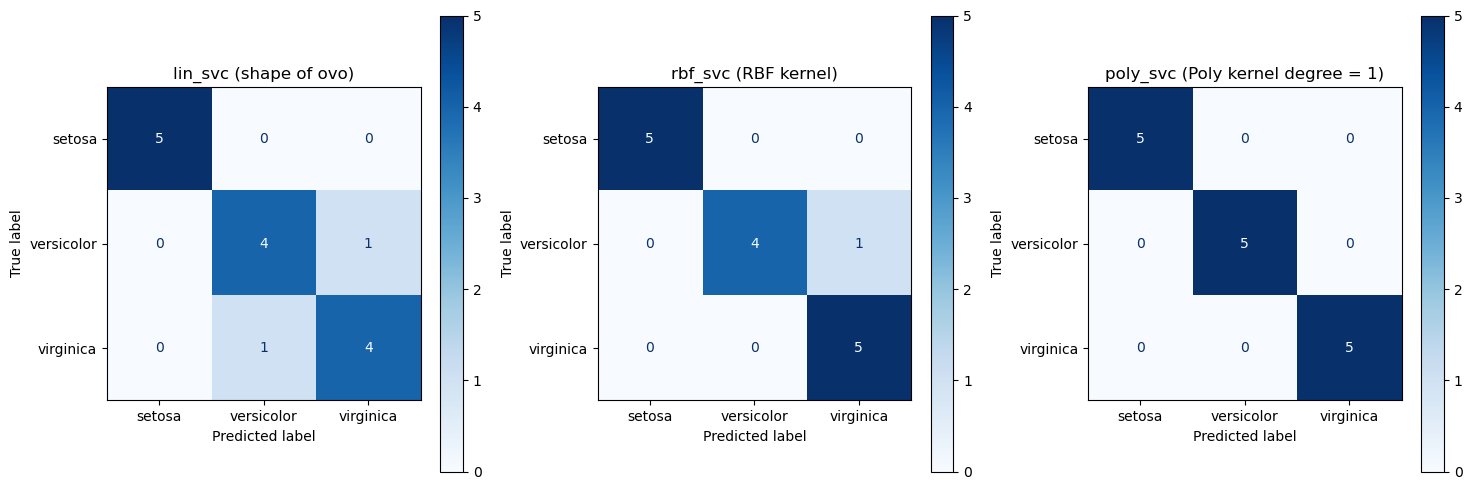

In [18]:
#代码
lin_svc = svm.SVC(decision_function_shape='ovo', kernel = 'rbf', gamma = 'auto') 
lin_svc.fit(X_train,y_train)            
lin_y_pred = lin_svc.predict(X_test)

rbf_svc = svm.SVC(decision_function_shape='ovo',kernel='linear')
rbf_svc.fit(X_train, y_train)
rbf_pred = rbf_svc.predict(X_test)

poly_svc = svm.SVC(decision_function_shape = 'ovo', kernel = 'poly',degree = 1)
poly_svc.fit(X_train, y_train)
poly_pred = poly_svc.predict(X_test)

print("lin_svc(ovo)精度",lin_svc.score(X_test,y_test))
print("rbf_svc精度：",rbf_svc.score(X_test,y_test))
print("poly_svc精度：",poly_svc.score(X_test,y_test))

cm_lin = confusion_matrix(y_test, lin_y_pred)
cm_rbf = confusion_matrix(y_test, rbf_pred)
cm_poly = confusion_matrix(y_test, poly_pred)

# 打印混淆矩阵
print("lin_svc(ovo)混淆矩阵:\n", cm_lin)
print("rbf_svc(ovo)混淆矩阵:\n", cm_rbf)
print("poly_svc(ovo)混淆矩阵:\n", cm_poly)

# 绘制混淆矩阵图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lin, display_labels=iris_data.target_names)
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('lin_svc (shape of ovo)')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=iris_data.target_names)
disp.plot(ax=axes[1], cmap='Blues')
axes[1].set_title('rbf_svc (RBF kernel)')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly, display_labels=iris_data.target_names)
disp.plot(ax=axes[2], cmap='Blues')
axes[2].set_title('poly_svc (Poly kernel degree = 1)')

plt.tight_layout()
plt.show()

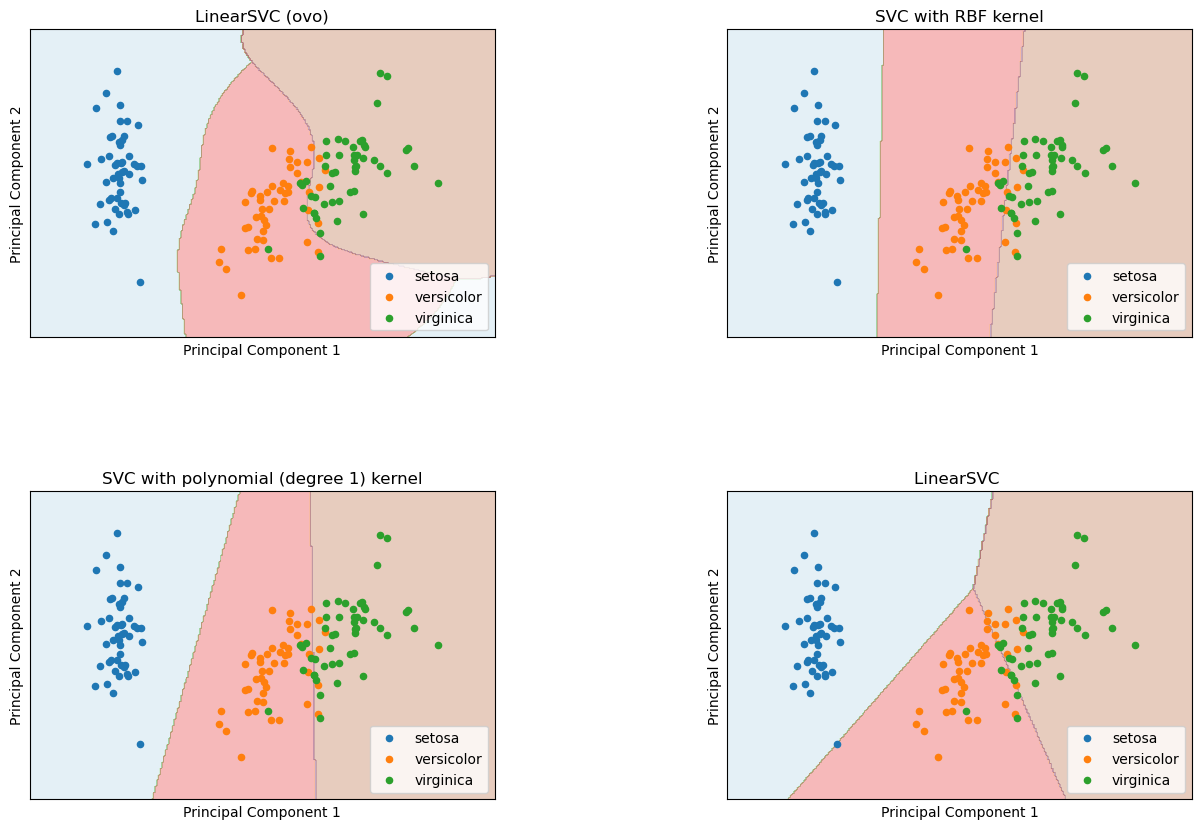

In [19]:
# the step of the grid
h = .03
# to create the grid , so that we can plot the images on it
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
# the title of the graph
titles = ['LinearSVC (ovo)',
          'SVC with RBF kernel',
          'SVC with polynomial (degree 1) kernel',
          'LinearSVC ']

# 设置图形大小
plt.figure(figsize=(15, 10))

for i, clf in enumerate((lin_svc, rbf_svc, poly_svc,lsvc)):
    plt.subplot(2, 2, i + 1) 
    plt.subplots_adjust(wspace=0.5, hspace=0.5)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]) 
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.3) 
    for target in set(iris_y):
        plt.scatter(X_pca[iris_y == target, 0], X_pca[iris_y == target, 1], label=iris_data.target_names[target], s=20)  # 减小散点大小
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])
    plt.legend()

plt.show()